<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/%20Caminata%20aleatoria%20sobre%20un%20grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:Brown;">**Caminata aleatoria sobre un grafo**</span>

<span style="color:blue;"> **Nombre:**</span> Florencio Florencio Miriam Lizeth

<span style="color:orange;"> ***Objetivo:*** </span>

Analizar una caminata aleatoria en un grafo de **cadenas binarias buenas**, donde no existen dos unos consecutivos, mediante una cadena de Markov y el método de Monte Carlo, con la finalidad de estimar el número esperado de unos en una cadena buena elegida aleatoriamente. Para ello, se comparará el resultado obtenido mediante la simulación con el valor exacto para $m=4$, y se estudiará cómo la estimación mejora al aumentar el número de iteraciones.


## <span style="color:ForestGreen;">**Cadenas Buenas**</span>

**Introducción**


La caminata aleatoria en un grafo es un proceso estocástico en el que un individuo o elemento se desplaza de un vértice a otro siguiendo las conexiones existentes, de acuerdo con ciertas probabilidades de transición. Este modelo permite estudiar cómo se mueve entre los diferentes estados de una red y analizar su comportamiento a lo largo del tiempo.

Por otra parte, las cadenas buenas se relacionan con las propiedades de las cadenas de Markov que permiten estudiar su evolución y comportamiento a largo plazo. Su análisis ayuda a comprender si es posible alcanzar diferentes estados, cómo se distribuyen las probabilidades y bajo qué condiciones el sistema puede converger a una distribución estacionaria. Ambos conceptos son útiles para modelar fenómenos como las redes sociales, los sistemas de transporte y la navegación en internet.

Consideremos una secuencia de $0^{`s}$ y $1^{`s}$ de longitud $m$

Llamamos una **buena cadena** a la que no contiene $1^{`s}$ adyacentes.

Para $m=4$ ¿cuántas buenas cadenas hay?

R= $2\quad \times \quad 2 \quad \times \quad 2 \quad \times\quad 2=2^4=16$

Son todas las combinaciones que se pueden hacer


<span style="color:ForestGreen;">**Principio Fundamental del Conteo**</sapn>

* Las buenas cadenas son:
$$(0000),(1000),(0100),(0010),(0001),(1010),(0101),(1001) \quad : 8$$

* **La pregunta a resolver es: ¿Cuál es el numero esperado de $1^i$ si todas las buenas cadenas son igual de probables?**
$$$$


Para el caso general,<span style="color:ForestGreen;"> **de una cadena de longitud $m$**</span> el valor esperado de $1^{`s}$ es
$$μ \quad = \sum_k kπ_k$$

donde $π_k$ es la probabilidad de que una buena secuencia tenga $k\quad 1^{`s}$.

Si $x$ es una secuencia de $0^{`s}$ y $1^{`s}$ de la secuencia.
Si nos restringimos a simular **solo buenas cadenas** $Y_0,Y_1,Y_2,...$ podemos estimar las respuestas por el <span style="color:ForestGreen;"> **Método de Monte Carlo**</span>
$$μ\approx \frac{r(Y_0)+r(Y_1)+r(Y_2)+...r(Y_n)}{n}$$


*$$
\begin{array}{|c|c|c|c|c|}
2  & 2 & 2 & 2&
\hline
2 & 2& 2 & ... & 2 \\
\hline
\end{array}
\quad
\implies 2\quad \times \quad 2 \quad \times \quad 2 \quad \times\quad 2\quad \times \quad ...\quad \times \quad 2=2^m \quad
0\quad a\quad  1
$$




Podemos preceder por <span style="color:ForestGreen;"> **Aceptacion y Rechazo**</span>
* Generamos muchas cadenas y solo **guardamos buenas cadenas**.

**Por ejemplo:**
* Para $m=100$
* Habria $2^{100}\approx 10^{30}$

$2^{10}=1024$

$(2^{10}\approx 10^{3})^{10}$

$2^{100}\approx 10^{30}$

Si hay solamente $10^{21}$ **buenas cadenas**

La proporcion es $\frac{10^{21}}{10^{30}}=10^{-9}←$**Muestra que el procedimiento no es viable**


**Nota:** Encontraremos una buena cadena cada mil millones

### <span style="color:teal;">**ACTIVIDAD**</span>

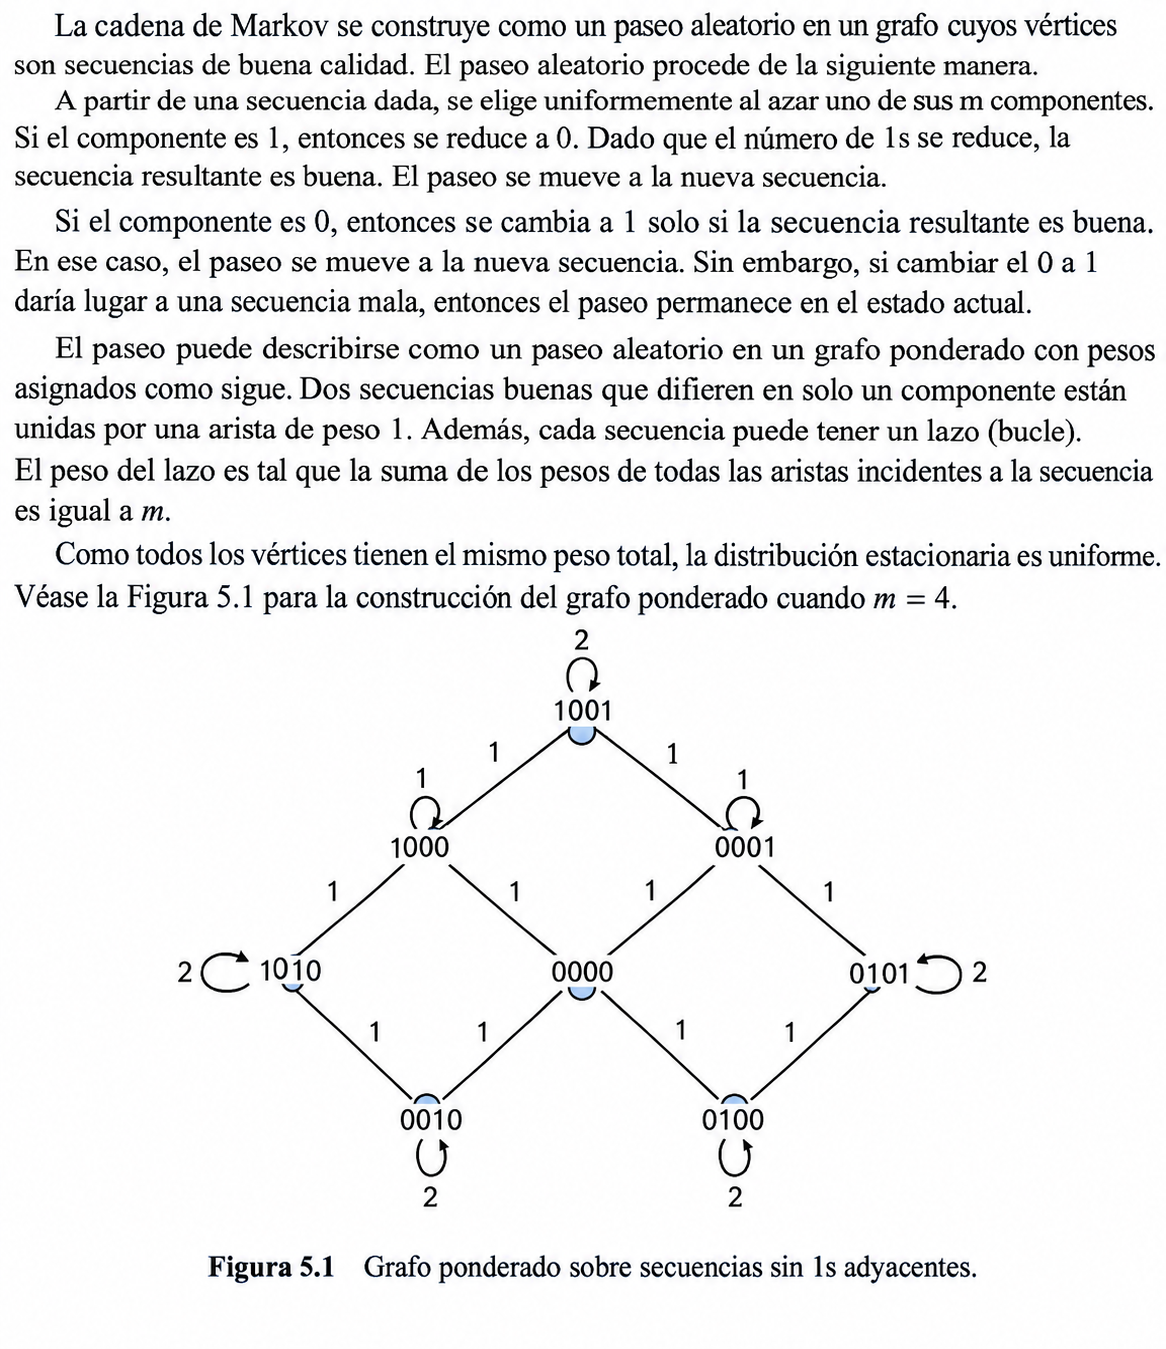

****

**RECORDATORIO**

Una cadena buena es aquella que NO contiene dos unos consecutivos.

Por ejemplo:
* 0000 -> Es buena
* 1010 -> Es buena
* 1100 -> No es buena, porque tiene dos unos adyacentes.

In [1]:
# Importamos las bibliotecas necesarias para realizar la actividad.
import random                  # Genera números aleatorios y elige posiciones.
import numpy as np             # Realiza cálculos numéricos y estadísticos.
import matplotlib.pyplot as plt  # Permite construir las gráficas.
from itertools import product  # Genera todas las combinaciones binarias.
import pandas as pd


### Determina si una cadena binaria es buena.

Una cadena es buena cuando no contiene dos unos consecutivos.

Parámetro:
cadena: lista o tupla formada por ceros y unos.

Regresa:

* True si la cadena es buena.
* False si contiene dos unos adyacentes.

In [2]:
# 1. FUNCIÓN PARA IDENTIFICAR LAS CADENAS BUENAS
def es_buena(cadena):

    # Recorremos las posiciones consecutivas de la cadena.
    for i in range(len(cadena) - 1):

        # Revisamos si la posición actual y la siguiente son unos.
        if cadena[i] == 1 and cadena[i + 1] == 1:

            # Si encontramos dos unos consecutivos, no es buena.
            return False

    # Si terminamos de revisar sin encontrar unos consecutivos,
    # entonces la cadena sí es buena.
    return True

Cuenta cuántos unos contiene una cadena binaria.
* Parámetro:
cadena; secuencia de ceros y unos.

* Regresa:
La suma de sus elementos, que equivale al número de unos.



In [3]:
# 2. FUNCIÓN PARA CONTAR LOS UNOS DE UNA CADENA
def numero_unos(cadena):
    # Sumamos los elementos: los ceros no aportan y cada uno aporta 1.
    return sum(cadena)


In [4]:
# 3. ENUMERACIÓN DE TODAS LAS CADENAS PARA m = 4

# Definimos la longitud de las cadenas binarias.
m = 4

# Generamos todas las combinaciones posibles de ceros y unos.
# Como cada posición puede tomar dos valores, existen 2^m cadenas.
todas_las_cadenas = list(product([0, 1], repeat=m))

# Filtramos las combinaciones y conservamos únicamente las buenas.
cadenas_buenas = [
    cadena
    for cadena in todas_las_cadenas
    if es_buena(cadena)
]

# Calculamos el número esperado exacto de unos.
# Primero contamos los unos de cada cadena buena y después
# calculamos el promedio, suponiendo que todas son equiprobables.
esperanza_exacta = np.mean([
    numero_unos(cadena)
    for cadena in cadenas_buenas
])



In [5]:

# 4. MOSTRAR LAS CADENAS BUENAS Y EL RESULTADO EXACTO

# Imprimimos un encabezado para organizar los resultados.
print("=" * 60)
print("ENUMERACIÓN DE LAS CADENAS BUENAS")
print("=" * 60)

# Mostramos la longitud utilizada.
print(f"Longitud de las cadenas (m): {m}")

# Mostramos el total de combinaciones binarias posibles.
print(f"Total de cadenas posibles: {2**m}")

# Mostramos cuántas cadenas cumplen la condición de ser buenas.
print(f"Total de cadenas buenas: {len(cadenas_buenas)}")

ENUMERACIÓN DE LAS CADENAS BUENAS
Longitud de las cadenas (m): 4
Total de cadenas posibles: 16
Total de cadenas buenas: 8


In [6]:
# Recorremos todas las cadenas buenas encontradas.
for cadena in cadenas_buenas:

    # Convertimos la tupla de números en una cadena de texto.
    cadena_texto = "".join(map(str, cadena))

    # Contamos los unos que contiene la cadena actual.
    cantidad_unos = numero_unos(cadena)

    # Imprimimos la cadena y su cantidad de unos.
    print(f"Cadena: {cadena_texto} | Número de unos: {cantidad_unos}")

# Mostramos la esperanza matemática calculada exactamente.
print(f"\nEsperanza exacta de unos: {esperanza_exacta:.4f}")

Cadena: 0000 | Número de unos: 0
Cadena: 0001 | Número de unos: 1
Cadena: 0010 | Número de unos: 1
Cadena: 0100 | Número de unos: 1
Cadena: 0101 | Número de unos: 2
Cadena: 1000 | Número de unos: 1
Cadena: 1001 | Número de unos: 2
Cadena: 1010 | Número de unos: 2

Esperanza exacta de unos: 1.2500



Se simula una caminata aleatoria sobre el grafo de cadenas buenas.

* Reglas del movimiento:
    1. Se comienza con una cadena de ceros.
    2. Se elige una posición uniformemente al azar.
    3. Se propone cambiar el cero por uno o el uno por cero.
    4. Si la nueva cadena es buena, se acepta el cambio.
    5. Si no es buena, se conserva la cadena actual.
    6. Se registra el número de unos después del periodo de quemado.

* Parámetros:
        m: longitud de la cadena.
        pasos: número de iteraciones que se utilizarán.
        quemado: iteraciones iniciales que se descartan.

* Regresa:
        resultados: número de unos observado en cada iteración.
        promedios: promedio acumulado de unos.



In [8]:
# 5. FUNCIÓN PARA REALIZAR LA CAMINATA ALEATORIA

def caminata_aleatoria(m, pasos, quemado=1000, mostrar_pasos=True):

    # Comenzamos con una cadena formada únicamente por ceros.
    estado = [0] * m

    # Listas para guardar resultados y promedios.
    resultados = []
    promedios = []

    # Inicializamos los acumuladores.
    suma_unos = 0
    total_muestras = 0

    # Ejecutamos los pasos más el periodo de quemado.
    for paso in range(pasos + quemado):

        # Elegimos una posición aleatoria.
        posicion = random.randrange(m)

        # Proponemos un nuevo estado.
        candidato = estado.copy()
        candidato[posicion] = 1 - candidato[posicion]

        # Verificamos si la cadena propuesta es buena.
        aceptado = es_buena(candidato)

        if aceptado:
            estado = candidato.copy()

        # Después del quemado, guardamos las observaciones.
        if paso >= quemado:

            # Contamos los unos del estado actual.
            unos = numero_unos(estado)

            # Guardamos el resultado.
            resultados.append(unos)

            # Actualizamos la suma y el número de muestras.
            suma_unos += unos
            total_muestras += 1

            # Calculamos el promedio acumulado.
            promedio_actual = suma_unos / total_muestras
            promedios.append(promedio_actual)

    # Mostramos únicamente el resumen final.
    if mostrar_pasos:
        print("=" * 50)
        print("RESUMEN DE LA CAMINATA ALEATORIA")
        print("=" * 50)
        print(f"Longitud de la cadena (m): {m}")
        print(f"Pasos solicitados: {pasos}")
        print(f"Periodo de quemado: {quemado}")
        print(f"Total de pasos realizados: {pasos + quemado}")
        print(f"Total de observaciones guardadas: {total_muestras}")
        print(f"Promedio final de unos: {promedios[-1]:.4f}")
        print("=" * 50)

    # Devolvemos los resultados y los promedios.
    return np.array(resultados), np.array(promedios)

In [9]:
# 6. CONFIGURACIÓN Y EJECUCIÓN DE MONTE CARLO


# Fijamos la semilla para poder reproducir los resultados.
random.seed(42)
np.random.seed(42)

# Definimos cuántas iteraciones se utilizarán para la estimación.
pasos = 100_000

# Definimos el número de iteraciones iniciales que descartaremos.
quemado = 5_000

# Ejecutamos la caminata aleatoria.
# La función devuelve las observaciones y los promedios acumulados.
muestras, promedios = caminata_aleatoria(
    m=m,
    pasos=pasos,
    quemado=quemado
)

# Calculamos la esperanza estimada mediante el promedio de las muestras.
esperanza_mc = np.mean(muestras)

# Calculamos la diferencia absoluta entre el valor exacto
# y el valor aproximado obtenido mediante la simulación.
error = abs(esperanza_exacta - esperanza_mc)


RESUMEN DE LA CAMINATA ALEATORIA
Longitud de la cadena (m): 4
Pasos solicitados: 100000
Periodo de quemado: 5000
Total de pasos realizados: 105000
Total de observaciones guardadas: 100000
Promedio final de unos: 1.2502


In [10]:

# 7. PRESENTACIÓN DE LOS RESULTADOS DE LA SIMULACIÓN


# Creamos la tabla con los resultados obtenidos.
tabla_resultados = pd.DataFrame({
    "Indicador": [
        "Número de muestras",
        "Esperanza exacta",
        "Esperanza estimada por Monte Carlo",
        "Error absoluto"
    ],
    "Resultado": [
        f"{len(muestras):,}",
        f"{esperanza_exacta:.4f}",
        f"{esperanza_mc:.4f}",
        f"{error:.4f}"
    ]
})

# Imprimimos el encabezado.
print("\n" + "=" * 58)
print("       RESULTADOS DEL MÉTODO DE MONTE CARLO")
print("=" * 58)

# Mostramos la tabla.
print(tabla_resultados.to_string(index=False))

print("=" * 58)


       RESULTADOS DEL MÉTODO DE MONTE CARLO
                         Indicador Resultado
                Número de muestras   100,000
                  Esperanza exacta    1.2500
Esperanza estimada por Monte Carlo    1.2502
                    Error absoluto    0.0002


En esa tabla se observa la comparación de resultados entre el análisis matemático exacto y la simulaciónpor el **Método de Monte Carlo**  para una cadena de longitud $m = 4$$m = 4$:

* Número de muestras (100,000): Es la cantidad de observaciones que generó la simulación después de pasar el período de calentamiento o quemado (burn-in). Es un tamaño de muestra muy grande y robusto para asegurar precisión estadística.

* Esperanza exacta (1.2500): Es el promedio real teórico. Si listáramos las 8 únicas cadenas buenas posibles de longitud 4, sumáramos todos sus unos y dividiéramos entre 8, el promedio matemático exacto es exactamente $1.25$$1.25$ (es decir, en promedio esperamos tener $1.25$$1.25$ unos por cadena).

* Esperanza estimada por Monte Carlo (1.2502): Es el promedio obtenido de manera empírica por tu simulación de cadenas de Markov. Como ves, el valor aproximado es extremadamente cercano al teórico.

* Error absoluto (0.0002): Es la diferencia directa entre el valor real y el aproximado ($|1.2500 - 1.2502| = 0.0002$$|1.2500 - 1.2502| = 0.0002$). Al ser un número tan pequeño, demuestra que la caminata aleatoria y el muestreo de Monte Carlo son sumamente efectivos para aproximar el comportamiento real del sistema sin tener que calcularlo analíticamente.

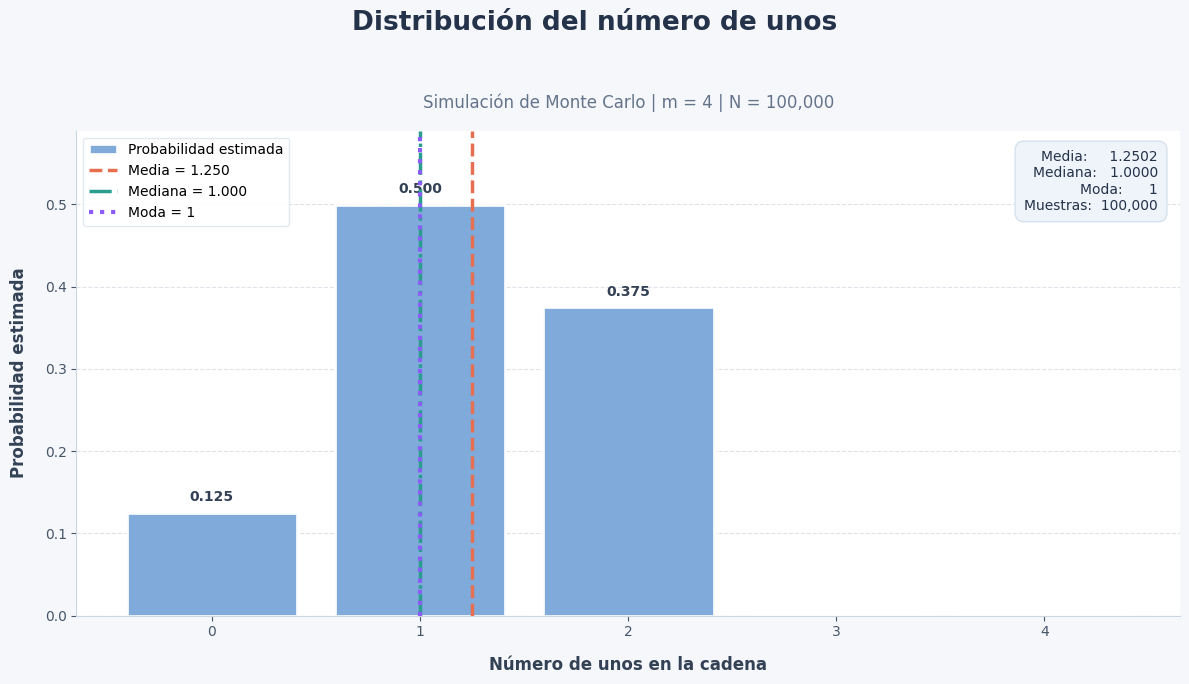


ESTADÍSTICOS DE LA DISTRIBUCIÓN
Número de simulaciones: 100,000
Media:                  1.2502
Mediana:                1.0000
Moda:                   1


In [11]:

# 8. DISTRIBUCIÓN DEL NÚMERO DE UNOS

# DATOS
N = len(muestras)

# ESTADÍSTICOS
media = np.mean(muestras)
mediana = np.median(muestras)

valores, frecuencias = np.unique(
    muestras,
    return_counts=True
)

moda = valores[np.argmax(frecuencias)]

# PROBABILIDADES ESTIMADAS
probabilidades = frecuencias / N

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor("#F5F7FB")
ax.set_facecolor("#FFFFFF")

fig.suptitle(
    "Distribución del número de unos",
    fontsize=19,
    fontweight="bold",
    color="#24324A",
    y=0.97
)

ax.set_title(
    f"Simulación de Monte Carlo | m = {m} | N = {N:,}",
    fontsize=12,
    color="#64748B",
    pad=16
)
# HISTOGRAMA DE PROBABILIDADES

conteos, bordes, barras = ax.hist(
    muestras,
    bins=np.arange(-0.5, m + 1.5, 1),
    weights=np.ones(N) / N,
    color="#78A6D8",
    edgecolor="#FFFFFF",
    linewidth=2,
    rwidth=0.82,
    alpha=0.95,
    label="Probabilidad estimada"
)

# ETIQUETAS SOBRE LAS BARRAS

for barra, altura in zip(barras, conteos):

    if altura > 0:
        ax.annotate(
            f"{altura:.3f}",
            xy=(
                barra.get_x() + barra.get_width() / 2,
                altura
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#334155"
        )
# LÍNEAS DE LOS ESTADÍSTICOS

ax.axvline(
    media,
    color="#E76F51",
    linestyle="--",
    linewidth=2.5,
    label=f"Media = {media:.3f}",
    zorder=4
)

ax.axvline(
    mediana,
    color="#2A9D8F",
    linestyle="-.",
    linewidth=2.5,
    label=f"Mediana = {mediana:.3f}",
    zorder=4
)

ax.axvline(
    moda,
    color="#8B5CF6",
    linestyle=":",
    linewidth=3,
    label=f"Moda = {moda}",
    zorder=4
)

# EJES Y FORMATO

ax.set_xlabel(
    "Número de unos en la cadena",
    fontsize=12,
    fontweight="bold",
    color="#334155",
    labelpad=12
)

ax.set_ylabel(
    "Probabilidad estimada",
    fontsize=12,
    fontweight="bold",
    color="#334155",
    labelpad=12
)

ax.set_xticks(range(m + 1))
ax.tick_params(axis="both", labelsize=10, colors="#475569")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30,
    color="#94A3B8"
)

ax.set_axisbelow(True)

# Eliminamos bordes innecesarios.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")

# RECUADRO DE ESTADÍSTICOS


texto = (
    f"Media:     {media:.4f}\n"
    f"Mediana:   {mediana:.4f}\n"
    f"Moda:      {moda}\n"
    f"Muestras:  {N:,}"
)

ax.text(
    0.98,
    0.96,
    texto,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    color="#24324A",
    bbox=dict(
        boxstyle="round,pad=0.65",
        facecolor="#EEF4FA",
        edgecolor="#D5E1EF",
        alpha=0.98
    )
)

# LEYENDA Y AJUSTES FINALES

ax.legend(
    loc="upper left",
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="#E2E8F0",
    framealpha=0.95)

ax.margins(y=0.18)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()


print("\n" + "=" * 45)
print("ESTADÍSTICOS DE LA DISTRIBUCIÓN")
print("=" * 45)
print(f"Número de simulaciones: {N:,}")
print(f"Media:                  {media:.4f}")
print(f"Mediana:                {mediana:.4f}")
print(f"Moda:                   {moda}")
print("=" * 45)

Podemos observar que:

* Las alturas de las barras representan la probabilidad estimada mediante Monte Carlo (frecuencia relativa) de obtener una cadena con una cantidad específica de unos ($0$$0$, $1$$1$ o $2$$2$ unos para $m=4$$m=4$).
* Puedes observar que la probabilidad de tener $1$$1$ solo uno es la más alta (aproximadamente $0.50$$0.50$ o $50\%$$50\%$), seguida por la de tener $2$$2$ unos (aproximadamente $0.375$$0.375$ o $37.5\%$$37.5\%$) y, finalmente, la de tener $0$$0$ unos (aproximadamente $0.125$$0.125$ o $12.5\%$$12.5\%$).
* La Media (Línea discontinua --): Se sitúa en un valor sumamente cercano a $1.2502$$1.2502$ (la esperanza exacta teórica es $1.2500$$1.2500$). Representa el valor esperado promedio a largo plazo de unos en la caminata.
* La Mediana (Línea punto-raya -.): Está en exactamente $1.0$$1.0$. Indica que al menos el $50\%$$50\%$ de las cadenas simuladas tienen $1$$1$ o menos unos.
La Moda (Línea punteada :): Se ubica en $1$$1$, lo que confirma visualmente que el estado con un único uno es el resultado que ocurre con mayor frecuencia en la caminata.
* Consistencia Estadística:
Al usar un número robusto de simulaciones ($N = 100,000$$N = 100,000$), la aproximación empírica calculada por la simulación estocástica coincide casi a la perfección con la probabilidad clásica teórica del espacio de estados.


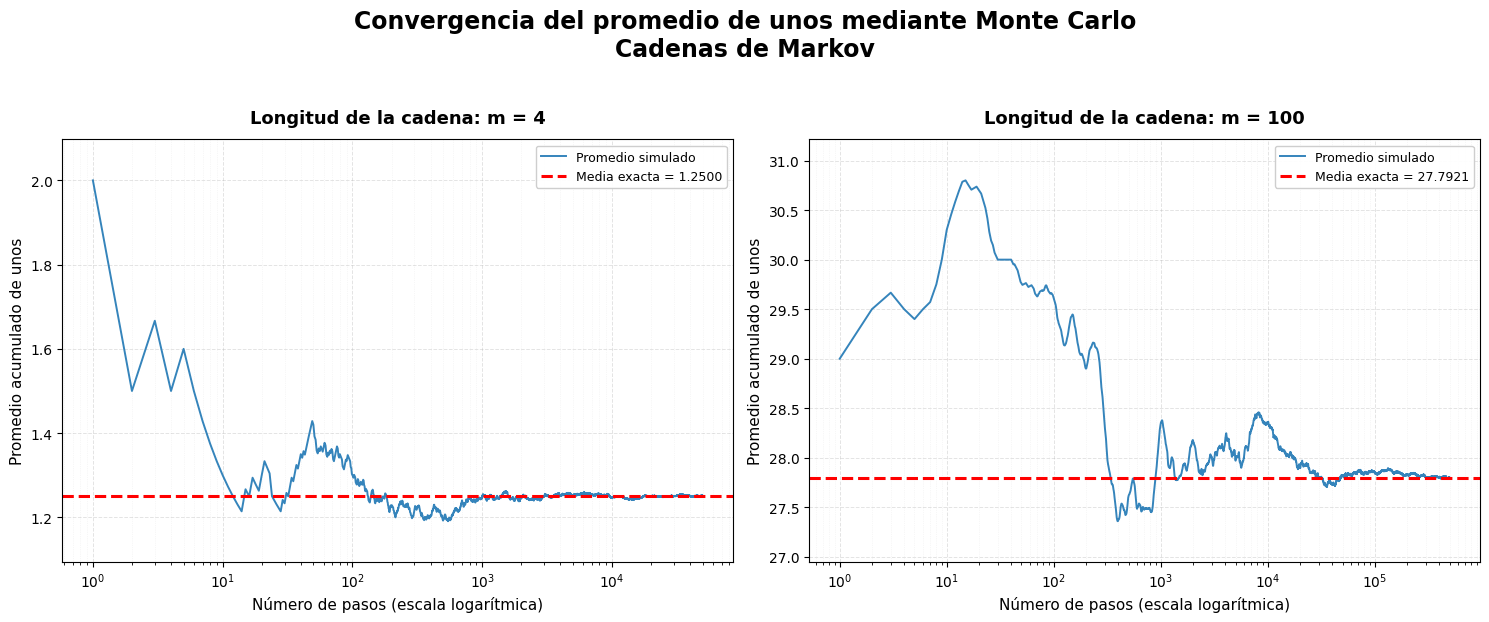

In [14]:
# 9. GRÁFICA DE CONVERGENCIA DE LA ESPERANZA

def historial(m, n):
    # Reutiliza la función ya definida para obtener los promedios acumulados
    _, promedios = caminata_aleatoria(m, pasos=n, quemado=1000, mostrar_pasos=False)
    return promedios

def media_exacta(m):
    # Calcula la cantidad exacta usando recurrencias (Fibonacci) para m grandes
    # dp_total[i] almacena el número de buenas cadenas de longitud i
    # dp_ones[i] almacena la suma total de unos en todas las buenas cadenas de longitud i
    dp_total = [0] * (max(4, m) + 1)
    dp_ones = [0] * (max(4, m) + 1)

    # Casos base
    # m = 1: [0], [1] (buenas cadenas: 2, total de unos: 1)
    dp_total[1] = 2
    dp_ones[1] = 1

    # m = 2: [00], [01], [10] (buenas cadenas: 3, total de unos: 2)
    dp_total[2] = 3
    dp_ones[2] = 2

    for i in range(3, m + 1):
        dp_total[i] = dp_total[i-1] + dp_total[i-2]
        dp_ones[i] = dp_ones[i-1] + dp_ones[i-2] + dp_total[i-2]

    return dp_ones[m] / dp_total[m]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Título general
fig.suptitle(
    "Convergencia del promedio de unos mediante Monte Carlo\n"
    "Cadenas de Markov",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# Configuración para cada gráfica
configuraciones = [
    (4, 50_000),
    (100, 500_000)]

for ax, (m, n) in zip(axes, configuraciones):

    # Calculamos el historial de promedios
    h = historial(m, n)

    # Calculamos la media exacta
    exacta = media_exacta(m)

    # Graficamos la convergencia del promedio
    ax.plot(np.arange(1, n + 1),
        h,
        linewidth=1.4,
        label="Promedio simulado",
        alpha=0.9)

    # Añadimos la media exacta
    ax.axhline(exacta,
        color="red",
        linestyle="--",
        linewidth=2.2,
        label=f"Media exacta = {exacta:.4f}")

    # Escala logarítmica en el eje horizontal
    ax.set_xscale("log")

    # Títulos y etiquetas
    ax.set_title(f"Longitud de la cadena: m = {m}",
        fontsize=13,
        fontweight="bold",
        pad=12)

    ax.set_xlabel("Número de pasos (escala logarítmica)", fontsize=11)
    ax.set_ylabel("Promedio acumulado de unos", fontsize=11)

    # Estilo de la cuadrícula
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35)

    ax.grid(True,
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.2)

    # Leyenda
    ax.legend(loc="best",
        fontsize=9,
        frameon=True,
        framealpha=0.95)

    # Evitamos que el eje vertical quede demasiado ajustado
    ax.margins(y=0.12)

# Ajustamos la distribución de los elementos
plt.tight_layout()

# Mostramos las gráficas
plt.show()

In [15]:

# 10. CONCLUSIÓN AUTOMÁTICA DE LA ACTIVIDAD

# Construimos la tabla con los resultados principales.
tabla_conclusion = pd.DataFrame({
    "Concepto": [
        "Longitud de la cadena",
        "Número de cadenas buenas",
        "Esperanza exacta",
        "Esperanza estimada por Monte Carlo",
        "Diferencia absoluta"
    ],
    "Resultado": [
        f"m = {m}",
        f"{len(cadenas_buenas):,}",
        f"{esperanza_exacta:.4f}",
        f"{esperanza_mc:.4f}",
        f"{error:.4f}"
    ]
})

# Imprimimos el encabezado.
print("\n" + "=" * 65)
print("           CONCLUSIÓN DE LA ACTIVIDAD")
print("=" * 65)

# Mostramos la tabla.
print(tabla_conclusion.to_string(index=False))

print("=" * 65)

# Interpretación automática de los resultados.
print("\nINTERPRETACIÓN:")

print(
    f"Para m = {m}, se encontraron "
    f"{len(cadenas_buenas):,} cadenas buenas."
)

print(
    f"La esperanza exacta es {esperanza_exacta:.4f}, "
    f"mientras que la estimación obtenida mediante "
    f"Monte Carlo es {esperanza_mc:.4f}."
)

print(
    f"La diferencia absoluta entre ambos resultados "
    f"es {error:.4f}."
)

# Conclusión general.
if np.isclose(esperanza_exacta, esperanza_mc):
    print(
        "\nConclusión: la estimación de Monte Carlo coincide "
        "aproximadamente con la esperanza exacta."
    )
else:
    print(
        "\nConclusión: Monte Carlo proporciona una aproximación "
        "a la esperanza exacta. La diferencia observada se debe "
        "a la variabilidad propia de la simulación."
    )

print("=" * 65)


           CONCLUSIÓN DE LA ACTIVIDAD
                          Concepto Resultado
             Longitud de la cadena   m = 100
          Número de cadenas buenas         8
                  Esperanza exacta    1.2500
Esperanza estimada por Monte Carlo    1.2502
               Diferencia absoluta    0.0002

INTERPRETACIÓN:
Para m = 100, se encontraron 8 cadenas buenas.
La esperanza exacta es 1.2500, mientras que la estimación obtenida mediante Monte Carlo es 1.2502.
La diferencia absoluta entre ambos resultados es 0.0002.

Conclusión: Monte Carlo proporciona una aproximación a la esperanza exacta. La diferencia observada se debe a la variabilidad propia de la simulación.



<span style="color:teal;">**Conclusión**</span>

En esta actividad se aplicó el método de Monte Carlo mediante una caminata aleatoria con cadenas de Markov para estimar el número esperado de unos en una cadena binaria, considerando únicamente aquellas cadenas que cumplen con las condiciones establecidas. A través de la simulación, fue posible observar cómo se pueden obtener resultados aproximados sin tener que analizar individualmente todas las cadenas posibles.

Al comparar la esperanza estimada por Monte Carlo con la esperanza exacta, se pudo identificar qué tan cercano fue el resultado de la simulación al valor teórico. Esto permitió comprender que, aunque los métodos numéricos pueden presentar pequeñas diferencias respecto a los resultados exactos, son herramientas útiles para estudiar problemas de probabilidad y obtener aproximaciones cuando el cálculo directo resulta complicado.

Además, esta actividad ayudó a comprender mejor cómo funciona una cadena de Markov y cómo puede utilizarse para recorrer distintas configuraciones válidas de una cadena binaria. En general, se pudo observar la importancia de combinar los conocimientos teóricos con la programación, ya que esto facilita la resolución de problemas probabilísticos y permite interpretar los resultados de una manera más práctica.